# Acquire external datasets

DRIMDB + IDRiD + DeepDRiD -> 512 px, one manifest -> Kaggle Dataset `retina-external-512`.

Attach first:
- `subhajournal/drimdb-diabetic-retinopathy-images-database`
- `mohamedabdalkader/indian-diabetic-retinopathy-image-dataset-idrid`
- `nancyhisham/deepdrid`

**Known issues handled below:** DRIMDB ships iWeb gallery exports (excluded by depth);
IDRiD upload merges two sources and renumbers each split from 0001 (filtered by native
resolution, split-prefixed ids).

## 1 · Setup

In [1]:
# =====================================================================
# SHARED HELPERS - identical copy in every notebook and in
# src/data/preprocess.py. Do not edit one without the others.
# =====================================================================
import os

import cv2
import numpy as np

TARGET = 512


def stem(s):
    return os.path.splitext(os.path.basename(str(s)))[0]


def crop_fov(img, tol=7):
    """Trim the black surround around the circular field of view."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > tol
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    return img[ys.min():ys.max() + 1, xs.min():xs.max() + 1]


def pad_square(img):
    """Pad the short side so resizing does not distort the retina."""
    h, w = img.shape[:2]
    s = max(h, w)
    t, l = (s - h) // 2, (s - w) // 2
    return cv2.copyMakeBorder(img, t, s - h - t, l, s - w - l,
                              cv2.BORDER_CONSTANT, value=[0, 0, 0])


def preprocess(img, size=TARGET):
    return cv2.resize(pad_square(crop_fov(img)), (size, size),
                      interpolation=cv2.INTER_AREA)


print("helpers defined")

helpers defined


In [2]:
import shutil
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

INPUT = Path("/kaggle/input")
WORK = Path("/kaggle/working")
OUT = WORK / "external_512"
OUT.mkdir(exist_ok=True)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}



GOOD, USABLE, REJECT = 0, 1, 2
SCHEMA = ["dataset", "image_id", "src_path", "patient_id",
          "quality_raw", "quality", "role", "dr_grade",
          "clarity", "field_def", "artifact"]

def resolve(slug, root=INPUT, max_depth=3):
    """Find an attached dataset by slug whatever the mount layout."""
    for depth in range(1, max_depth + 1):
        hits = [p for p in root.glob("/".join(["*"] * (depth - 1) + [slug]))
                if p.is_dir()]
        if hits:
            return hits[0]
    return None


DRIMDB = resolve("drimdb-diabetic-retinopathy-images-database")
IDRID = resolve("indian-diabetic-retinopathy-image-dataset-idrid")
DEEPDRID = resolve("deepdrid")

for n, p in [("DRIMDB", DRIMDB), ("IDRiD", IDRID), ("DeepDRiD", DEEPDRID)]:
    print(f"{n:10s} {'OK     ' if p else 'MISSING'} {p}")

DRIMDB     OK      /kaggle/input/datasets/subhajournal/drimdb-diabetic-retinopathy-images-database
IDRiD      OK      /kaggle/input/datasets/mohamedabdalkader/indian-diabetic-retinopathy-image-dataset-idrid
DeepDRiD   OK      /kaggle/input/datasets/nancyhisham/deepdrid


## 2 · Verify

In [3]:
EXPECTED = {"drimdb": 216, "idrid": 516, "deepdrid": 2256}


def verify(name, root, sample=25):
    print(f"\n{'=' * 64}\n{name}")
    if not root or not Path(root).exists():
        print("  NOT ATTACHED")
        return
    paths = [p for p in Path(root).rglob("*") if p.suffix.lower() in IMG_EXTS]
    print(f"  expected {EXPECTED[name]:,}   found {len(paths):,}")

    step = max(1, len(paths) // sample)
    dims = []
    for p in paths[::step][:sample]:
        try:
            with Image.open(p) as im:
                dims.append(im.size)
        except Exception:
            pass
    if dims:
        print(f"  sizes: {Counter(dims).most_common(3)}")


for n, r in [("drimdb", DRIMDB), ("idrid", IDRID), ("deepdrid", DEEPDRID)]:
    verify(n, r)


drimdb
  expected 216   found 651
  sizes: [((760, 570), 16), ((100, 75), 9)]

idrid
  expected 516   found 1,548
  sizes: [((4880, 3862), 20), ((4288, 2848), 5)]

deepdrid
  expected 2,256   found 2,256
  sizes: [((1976, 1984), 13), ((1736, 1824), 9), ((3900, 3072), 2)]


## 3 · Explore DeepDRiD label files

In [4]:
def tree(root, max_depth=3, max_files=4):
    root = Path(root)
    for dirpath, dirnames, filenames in os.walk(root):
        parts = Path(dirpath).relative_to(root).parts
        if len(parts) > max_depth:
            dirnames.clear()
            continue
        ind = "   " * len(parts)
        print(f"{ind}{Path(dirpath).name or root.name}/  ({len(filenames)} files)")
        for f in sorted(filenames)[:max_files]:
            print(f"{ind}   {f}")
        if len(filenames) > max_files:
            print(f"{ind}   ... +{len(filenames) - max_files} more")


def find_tables(root, n=4):
    for dirpath, _, filenames in os.walk(root):
        for f in sorted(filenames):
            if not f.lower().endswith((".csv", ".xlsx", ".xls")):
                continue
            p = Path(dirpath) / f
            print(f"\n{'=' * 70}\n{p}")
            try:
                df = (pd.read_csv(p) if f.lower().endswith(".csv")
                      else pd.read_excel(p))
                print(f"shape={df.shape}  columns={list(df.columns)}")
                print(df.head(n).to_string(max_colwidth=26))
                for c in df.columns:
                    if df[c].dtype == object or df[c].nunique() <= 10:
                        print(f"  {c}: {df[c].value_counts().head(6).to_dict()}")
            except Exception as e:
                print(f"  could not read: {e}")


tree(DEEPDRID, max_depth=3)

deepdrid/  (2 files)
   LICENSE
   README.md
   regular_fundus_images/  (0 files)
      regular-fundus-training/  (4 files)
         .~Readme.docx
         Readme.docx
         regular-fundus-source-training.csv
         regular-fundus-training.csv
         Images/  (0 files)
      Online-Challenge1&2-Evaluation/  (6 files)
         .~Readme.docx
         Challenge1_labels.xlsx
         Challenge1_upload.csv
         Challenge2_labels.xlsx
         ... +2 more
         Images/  (0 files)
      regular-fundus-validation/  (4 files)
         .~Readme.docx
         Readme.docx
         regular-fundus-source-validation.csv
         regular-fundus-validation.csv
         Images/  (0 files)
   ultra-widefield_images/  (0 files)
      ultra-widefield-validation/  (2 files)
         Readme.txt
         ultra-widefield-validation.csv
         Images/  (0 files)
      ultra-widefield-training/  (2 files)
         Readme.txt
         ultra-widefield-training.csv
         Images/  (0 files)
      

In [5]:
find_tables(DEEPDRID / "regular_fundus_images")


/kaggle/input/datasets/nancyhisham/deepdrid/regular_fundus_images/regular-fundus-training/regular-fundus-source-training.csv
shape=(1200, 4)  columns=['patient_id', 'image_id', 'image_path', 'Source']
   patient_id image_id                 image_path   Source
0           1     1_l1  \regular-fundus-traini...  Nicheng
1           1     1_l2  \regular-fundus-traini...  Nicheng
2           1     1_r1  \regular-fundus-traini...  Nicheng
3           1     1_r2  \regular-fundus-traini...  Nicheng
  image_id: {'313_r2': 1, '313_r1': 1, '313_l2': 1, '313_l1': 1, '312_r2': 1, '312_r1': 1}
  image_path: {'\\regular-fundus-training\\313\\313_r2.jpg': 1, '\\regular-fundus-training\\313\\313_r1.jpg': 1, '\\regular-fundus-training\\313\\313_l2.jpg': 1, '\\regular-fundus-training\\313\\313_l1.jpg': 1, '\\regular-fundus-training\\312\\312_r2.jpg': 1, '\\regular-fundus-training\\312\\312_r1.jpg': 1}
  Source: {'Nicheng': 1140, 'Nation': 36, 'Shanghai': 24}

/kaggle/input/datasets/nancyhisham/deepdrid/

## 4 · Loaders

In [6]:
# ---------------------------------------------------------------------
# CROSSWALK - keep in sync with docs/crosswalk.md
#   DRIMDB   Good->0, Bad->2, Outlier dropped. Binary source: the Usable
#            middle class cannot be recovered, so DRIMDB is excluded from
#            3-class evaluation and reported on a collapsed binary task.
#   DeepDRiD binary overall quality. VERIFY DIRECTION before trusting.
#   IDRiD    all high quality -> 0. Control set only.
# ---------------------------------------------------------------------
DRIMDB_MAP = {"good": GOOD, "bad": REJECT}       # outlier deliberately absent
DEEPDRID_MAP = {1: GOOD, 0: REJECT}              # <-- VERIFY THIS

IDRID_NATIVE = (4288, 2848)


def _check(df, name):
    missing = set(SCHEMA) - set(df.columns)
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")
    if df.quality.isna().any():
        raise ValueError(f"{name}: {df.quality.isna().sum()} unmapped quality")
    if df.image_id.duplicated().any():
        raise ValueError(f"{name}: {df.image_id.duplicated().sum()} duplicate ids")
    return df[SCHEMA].reset_index(drop=True)

In [7]:
import re


def slug(s):
    s = re.sub(r"[^A-Za-z0-9]+", "_", str(s)).strip("_")
    return s[7:] if s.lower().startswith("drimdb_") else s


def load_drimdb(root=DRIMDB):
    """Good 125 + Bad 69 = 194. Immediate children of the class folder only -
    the nested iwebalbumfiles/ dirs are iWeb gallery exports."""
    rows = []
    for cls, q in DRIMDB_MAP.items():
        folder = next((d for d in Path(root).rglob("*")
                       if d.is_dir() and d.name.lower() == cls), None)
        if folder is None:
            print(f"  WARNING: no '{cls}' folder")
            continue
        for f in sorted(folder.iterdir()):        # iterdir, NOT rglob
            if f.suffix.lower() not in IMG_EXTS:
                continue
            iid = f"drimdb_{slug(stem(f))}"
            rows.append({"dataset": "drimdb", "image_id": iid,
                         "src_path": str(f), "patient_id": iid,
                         "quality_raw": cls, "quality": q,
                         "role": "external", "dr_grade": None,
                         "clarity": None, "field_def": None, "artifact": None})

    df = pd.DataFrame(rows)
    print(f"drimdb   : {len(df):4d}  {df.quality_raw.value_counts().to_dict()}")
    assert len(df) == 194, f"expected 194, got {len(df)}"
    return _check(df, "drimdb")


raw_dr = load_drimdb()
raw_dr.head()

drimdb   :  194  {'good': 125, 'bad': 69}


,dataset,image_id,src_path,patient_id,quality_raw,quality,role,dr_grade,clarity,field_def,artifact
0,drimdb,drimdb_good_1,/kaggle/input/datasets/subhajournal/drimdb-dia...,drimdb_good_1,good,0,external,None,None,None,None
1,drimdb,drimdb_good_10,/kaggle/input/datasets/subhajournal/drimdb-dia...,drimdb_good_10,good,0,external,None,None,None,None
2,drimdb,drimdb_good_100,/kaggle/input/datasets/subhajournal/drimdb-dia...,drimdb_good_100,good,0,external,None,None,None,None
3,drimdb,drimdb_good_101,/kaggle/input/datasets/subhajournal/drimdb-dia...,drimdb_good_101,good,0,external,None,None,None,None
4,drimdb,drimdb_good_102,/kaggle/input/datasets/subhajournal/drimdb-dia...,drimdb_good_102,good,0,external,None,None,None,None


In [8]:
def load_idrid(root=IDRID, native=IDRID_NATIVE):
    """Genuine IDRiD only, identified by native resolution.

    Upload merges two sources: 516 at 4288x2848 (IDRiD, matches the published
    count) and 1032 at 4880x3862 (different aspect ratio, unknown provenance).
    Train and Test each renumber from 0001, so ids carry the split name.
    """
    rows = []
    for csv in sorted(Path(root).rglob("annotations.csv")):
        split = csv.parent.name.lower()           # Train / Test, not IDRiD
        img_dir = csv.parent / "images"
        ann = pd.read_csv(csv).set_index("Image name")
        kept = skipped = 0

        for p in sorted(img_dir.iterdir()):
            if p.suffix.lower() not in IMG_EXTS:
                continue
            with Image.open(p) as im:             # header only
                if im.size != native:
                    skipped += 1
                    continue
            iid = f"idrid_{split}_{stem(p)}"
            rows.append({"dataset": "idrid", "image_id": iid,
                         "src_path": str(p), "patient_id": iid,
                         "quality_raw": "high", "quality": GOOD,
                         "role": "control",
                         "dr_grade": ann["Retinopathy grade"].get(p.name),
                         "clarity": None, "field_def": None, "artifact": None})
            kept += 1

        print(f"  {split:6s}: kept {kept:4d}, skipped {skipped:4d}")

    df = pd.DataFrame(rows)
    print(f"idrid    : {len(df):4d} at native resolution")
    print(f"           grades {df.dr_grade.value_counts().sort_index().to_dict()}")
    assert len(df) == 516, f"expected 516, got {len(df)}"
    return _check(df, "idrid")


raw_id = load_idrid()
raw_id.head()

  test  : kept  103, skipped  206
  train : kept  413, skipped  826
idrid    :  516 at native resolution
           grades {0: 168, 1: 25, 2: 168, 3: 93, 4: 62}


,dataset,image_id,src_path,patient_id,quality_raw,quality,role,dr_grade,clarity,field_def,artifact
0,idrid,idrid_test_IDRiD_0006,/kaggle/input/datasets/mohamedabdalkader/india...,idrid_test_IDRiD_0006,high,0,control,2,None,None,None
1,idrid,idrid_test_IDRiD_0011,/kaggle/input/datasets/mohamedabdalkader/india...,idrid_test_IDRiD_0011,high,0,control,3,None,None,None
2,idrid,idrid_test_IDRiD_0013,/kaggle/input/datasets/mohamedabdalkader/india...,idrid_test_IDRiD_0013,high,0,control,2,None,None,None
3,idrid,idrid_test_IDRiD_0016,/kaggle/input/datasets/mohamedabdalkader/india...,idrid_test_IDRiD_0016,high,0,control,3,None,None,None
4,idrid,idrid_test_IDRiD_0017,/kaggle/input/datasets/mohamedabdalkader/india...,idrid_test_IDRiD_0017,high,0,control,0,None,None,None


### DeepDRiD — set the three column names from cell 8 output

Keep the artifacts / clarity / field-definition sub-scores in mind: they are your only
real defect labels for Week 9.

In [9]:
def load_deepdrid(root=DEEPDRID):
    """Regular fundus only. Ultra-widefield is a different modality.

    Name the label CSVs explicitly - regular-fundus-source-*.csv also exist
    and carry no quality column, so a glob silently poisons the join.
    Clarity / Field definition / Artifact are the real defect labels used in
    Week 9 to validate the synthetic degradation pipeline.
    """
    reg = Path(root) / "regular_fundus_images"
    want = {"regular-fundus-training.csv", "regular-fundus-validation.csv"}
    csvs = sorted(p for p in reg.rglob("*.csv") if p.name.lower() in want)
    print("label files:", [p.name for p in csvs])

    lab = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
    print(f"{len(lab)} labelled rows")
    print("Overall quality:", lab["Overall quality"].value_counts().to_dict())

    index = {stem(p): str(p) for p in reg.rglob("*")
             if p.suffix.lower() in IMG_EXTS}
    lab["stem"] = lab["image_id"].map(stem)
    lab["src_path"] = lab["stem"].map(index)
    miss = lab.src_path.isna().sum()
    if miss:
        print(f"WARNING: {miss} labelled images not on disk")
    lab = lab.dropna(subset=["src_path", "Overall quality"]).drop_duplicates("stem")

    df = pd.DataFrame({
        "dataset": "deepdrid",
        "image_id": "deepdrid_" + lab["stem"],
        "src_path": lab["src_path"],
        "patient_id": "deepdrid_" + lab["patient_id"].astype(str),
        "quality_raw": lab["Overall quality"].astype(int),
        "quality": lab["Overall quality"].astype(int).map(DEEPDRID_MAP),
        "role": "external",
        "dr_grade": lab["patient_DR_Level"],
        "clarity": lab["Clarity"],
        "field_def": lab["Field definition"],
        "artifact": lab["Artifact"],
    })

    print(f"deepdrid : {len(df):4d}  {df.quality_raw.value_counts().to_dict()}")
    print(f"           {df.patient_id.nunique()} patients "
          f"({len(df) / df.patient_id.nunique():.1f} images each)")
    return _check(df, "deepdrid")


raw_dd = load_deepdrid()
raw_dd.head()

label files: ['regular-fundus-training.csv', 'regular-fundus-validation.csv']
1600 labelled rows
Overall quality: {0: 842, 1: 758}
deepdrid : 1600  {0: 842, 1: 758}
           400 patients (4.0 images each)


,dataset,image_id,src_path,patient_id,quality_raw,quality,role,dr_grade,clarity,field_def,artifact
0,deepdrid,deepdrid_1_l1,/kaggle/input/datasets/nancyhisham/deepdrid/re...,deepdrid_1,0,2,external,0,8,8,4
1,deepdrid,deepdrid_1_l2,/kaggle/input/datasets/nancyhisham/deepdrid/re...,deepdrid_1,0,2,external,0,8,8,0
2,deepdrid,deepdrid_1_r1,/kaggle/input/datasets/nancyhisham/deepdrid/re...,deepdrid_1,0,2,external,0,8,8,4
3,deepdrid,deepdrid_1_r2,/kaggle/input/datasets/nancyhisham/deepdrid/re...,deepdrid_1,0,2,external,0,10,8,0
4,deepdrid,deepdrid_2_l1,/kaggle/input/datasets/nancyhisham/deepdrid/re...,deepdrid_2,0,2,external,2,10,8,6


## 5 · Verify the DeepDRiD label direction

If this is inverted nothing errors — you get wrong results in Week 11 with no trace.

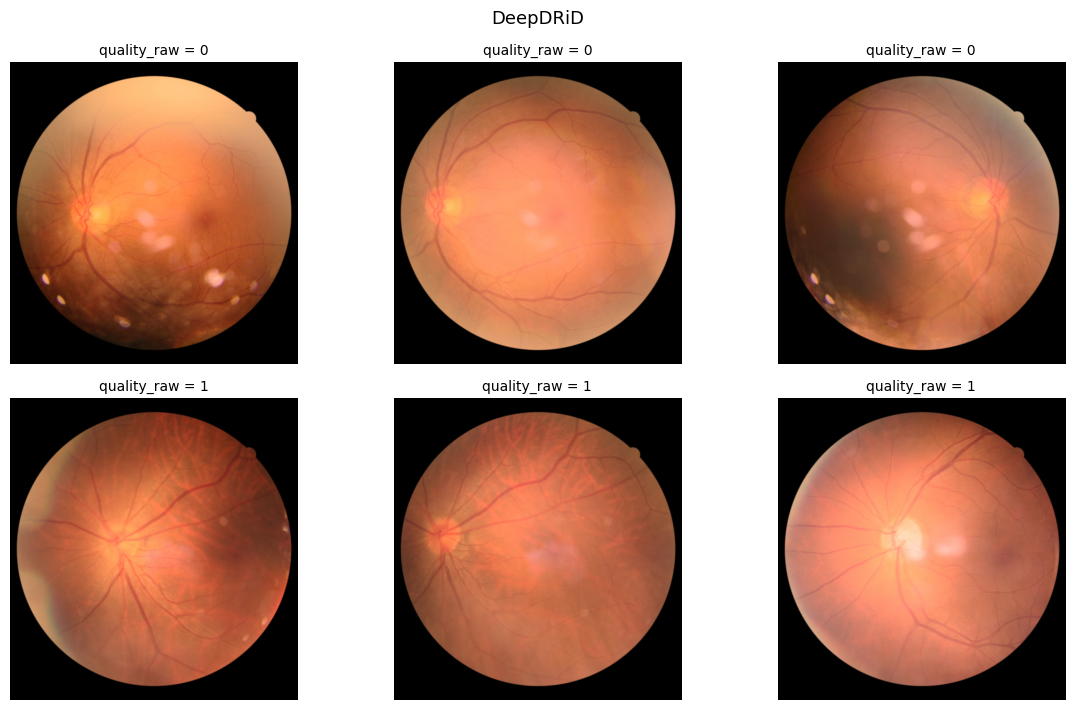

In [10]:
def peek_by_label(df, path_col, label_col, n=3, title=""):
    labels = sorted(df[label_col].dropna().unique())
    fig, axes = plt.subplots(len(labels), n, figsize=(4 * n, 3.6 * len(labels)))
    axes = np.atleast_2d(axes)
    for r, lab in enumerate(labels):
        for ax in axes[r]:
            ax.axis("off")
        for ax, (_, row) in zip(axes[r], df[df[label_col] == lab].head(n).iterrows()):
            img = cv2.imread(str(row[path_col]))
            if img is None:
                continue
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{label_col} = {lab}", fontsize=10)
    if title:
        plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


peek_by_label(raw_dd, "src_path", "quality_raw", title="DeepDRiD")

In [11]:
raw = pd.concat([raw_dr, raw_id, raw_dd], ignore_index=True)
print(f"total {len(raw)}\n")
print(raw.groupby(["dataset", "role", "quality"]).size().unstack(fill_value=0))

total 2310

quality              0    2
dataset  role              
deepdrid external  758  842
drimdb   external  125   69
idrid    control   516    0


## 5b · Is `DEEPDRID_MAP` the right way round?

The visual check is hard on DeepDRiD — good and bad are genuinely subtle there, which
is why the best result in the official ISBI 2020 challenge was only 69.81%.

So decide it objectively instead. DeepDRiD ships three sub-scores alongside the binary
overall label: **Clarity**, **Field definition** and **Artifact**. Whichever value of
`Overall quality` has higher clarity, better field definition and fewer artifacts is
the *good* one.

Run this before cell 21. If it says FLIP, change `DEEPDRID_MAP` in cell 10, then re-run
cells 14, 17 and 21 only — the preprocessed images are unaffected, just the manifest.

In [12]:
# ── Does Overall quality agree with the sub-scores? ────────────────
sub = raw_dd.copy()
for c in ("clarity", "field_def", "artifact"):
    sub[c] = pd.to_numeric(sub[c], errors="coerce")

print("mean sub-scores by raw Overall quality")
print(sub.groupby("quality_raw")[["clarity", "field_def", "artifact"]]
        .agg(["mean", "count"]).round(2))

means = sub.groupby("quality_raw")[["clarity", "field_def"]].mean()
arte = sub.groupby("quality_raw")["artifact"].mean()

best_visibility = means.mean(axis=1).idxmax()    # higher clarity + field = better
fewest_artifacts = arte.idxmin()                 # lower artifact score = better

print(f"\nhigher clarity / field definition -> quality_raw = {best_visibility}")
print(f"fewer artifacts                   -> quality_raw = {fewest_artifacts}")

if best_visibility == fewest_artifacts:
    good = int(best_visibility)
    want = {good: GOOD, 1 - good: REJECT}
    print(f"\nCONSISTENT: Overall quality = {good} means GOOD")
    print(f"  DEEPDRID_MAP should be : {want}")
    print(f"  currently              : {DEEPDRID_MAP}")
    print("  ->", "CORRECT, leave it" if DEEPDRID_MAP == want
          else "FLIP IT, then re-run cells 10, 14, 17, 21")
else:
    print("\nINCONSISTENT - the sub-scores disagree with each other.")
    print("Fall back to the visual check in cell 21.")

mean sub-scores by raw Overall quality
            clarity       field_def       artifact      
               mean count      mean count     mean count
quality_raw                                             
0              7.11   842      7.60   842     4.11   842
1              8.66   758      7.98   758     1.27   758

higher clarity / field definition -> quality_raw = 1
fewer artifacts                   -> quality_raw = 1

CONSISTENT: Overall quality = 1 means GOOD
  DEEPDRID_MAP should be : {1: 0, 0: 2}
  currently              : {1: 0, 0: 2}
  -> CORRECT, leave it


In [13]:
# ── Is Overall quality per-image or per-patient? ───────────────────
# Each patient contributes 4 images (2 eyes x 2 fields). If the label never
# varies within a patient it is an aggregate, not a per-image judgement -
# which changes how the generalisation result should be described.
mixed = (raw_dd.groupby("patient_id")["quality_raw"].nunique() > 1).sum()
total = raw_dd.patient_id.nunique()

print(f"patients with mixed quality labels: {mixed} of {total} "
      f"({mixed / total:.0%})")
print("\n-> per-image label" if mixed > total * 0.1
      else "\n-> looks like a patient- or eye-level label, not per-image")

patients with mixed quality labels: 143 of 400 (36%)

-> per-image label


In [14]:
# ── Source resolution by dataset, post-crop ────────────────────────
# DRIMDB is 760x570 natively - far smaller than EyeQ (2592x3888) or IDRiD
# (4288x2848). All three are resized to 512, but DRIMDB starts with far less
# fine detail. Worth one line in the report: it is part of why DRIMDB is easy.
for ds, g in raw.groupby("dataset"):
    sizes = []
    for p in g.src_path.head(20):
        try:
            with Image.open(p) as im:
                sizes.append(im.size)
        except Exception:
            pass
    print(f"{ds:10s} {Counter(sizes).most_common(2)}")

deepdrid   [((1736, 1824), 20)]
drimdb     [((760, 570), 20)]
idrid      [((4288, 2848), 20)]


## 6 · Preprocess

Identical pipeline to EyeQ. Do not special-case any dataset.

In [15]:
def convert(row, out_dir=OUT, size=TARGET):
    fname = f"{row.image_id}.png"
    dest = out_dir / fname
    if dest.exists():
        return fname
    img = cv2.imread(row.src_path)
    if img is None:
        return None
    cv2.imwrite(str(dest), preprocess(img, size))
    return fname


results, failed = [], []
for row in tqdm(raw.itertuples(), total=len(raw)):
    try:
        f = convert(row)
        if f is None:
            raise ValueError("decode failed")
        results.append(f)
    except Exception as e:
        results.append(None)
        failed.append((row.dataset, row.image_id, str(e)))

raw["filename"] = results
print(f"\nwritten {sum(r is not None for r in results)}   failed {len(failed)}")
if failed:
    pd.DataFrame(failed, columns=["dataset", "image_id", "error"]).to_csv(
        WORK / "external_failed.csv", index=False)

  0%|          | 0/2310 [00:00<?, ?it/s]


written 2310   failed 0


## 7 · Manifest

In [16]:
manifest = raw.dropna(subset=["filename"])[
    ["dataset", "image_id", "filename", "patient_id",
     "quality_raw", "quality", "role", "dr_grade", "src_path"]].copy()

manifest.to_csv(WORK / "manifest_external_512.csv", index=False)
print(manifest.shape)
print(manifest.groupby(["dataset", "role", "quality"]).size())
manifest.head()

(2310, 9)
dataset   role      quality
deepdrid  external  0          758
                    2          842
drimdb    external  0          125
                    2           69
idrid     control   0          516
dtype: int64


,dataset,image_id,filename,patient_id,quality_raw,quality,role,dr_grade,src_path
0,drimdb,drimdb_good_1,drimdb_good_1.png,drimdb_good_1,good,0,external,None,/kaggle/input/datasets/subhajournal/drimdb-dia...
1,drimdb,drimdb_good_10,drimdb_good_10.png,drimdb_good_10,good,0,external,None,/kaggle/input/datasets/subhajournal/drimdb-dia...
2,drimdb,drimdb_good_100,drimdb_good_100.png,drimdb_good_100,good,0,external,None,/kaggle/input/datasets/subhajournal/drimdb-dia...
3,drimdb,drimdb_good_101,drimdb_good_101.png,drimdb_good_101,good,0,external,None,/kaggle/input/datasets/subhajournal/drimdb-dia...
4,drimdb,drimdb_good_102,drimdb_good_102.png,drimdb_good_102,good,0,external,None,/kaggle/input/datasets/subhajournal/drimdb-dia...


## 8 · Check output

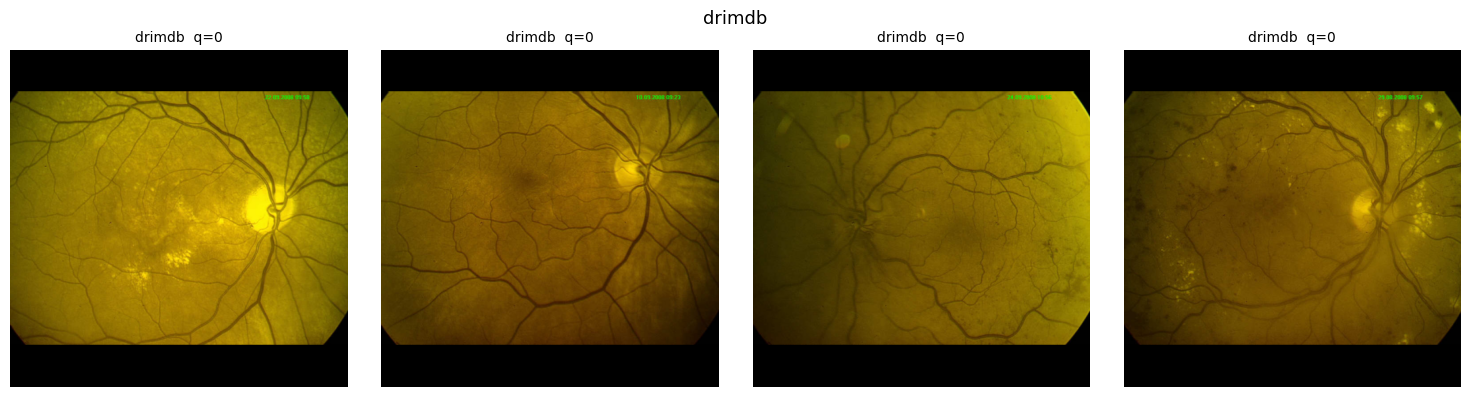

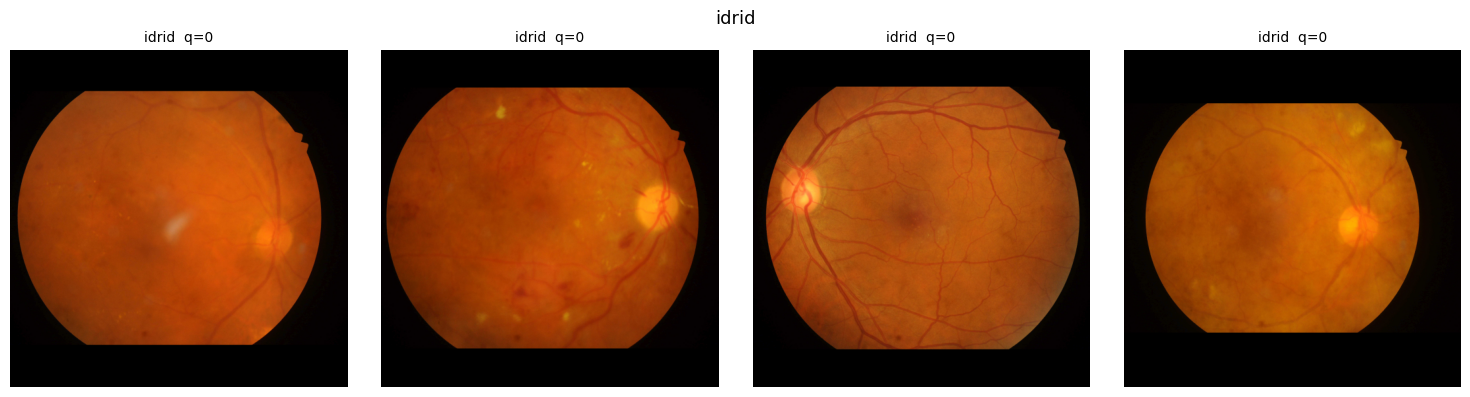

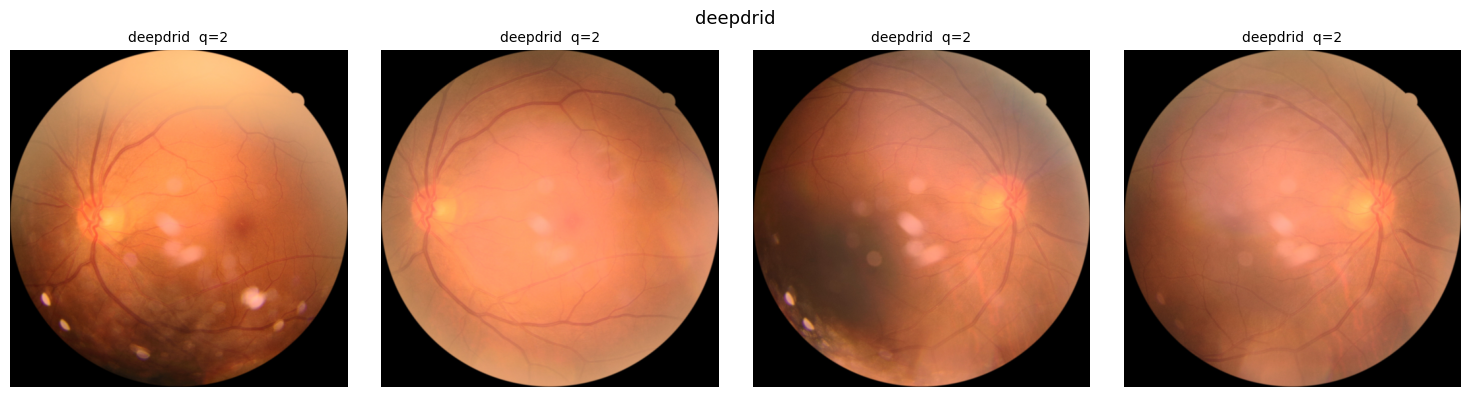

In [17]:
for ds in manifest.dataset.unique():
    sub = manifest[manifest.dataset == ds].head(4)
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for ax in axes:
        ax.axis("off")
    for ax, (_, r) in zip(axes, sub.iterrows()):
        img = cv2.imread(str(OUT / r.filename))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{ds}  q={r.quality}", fontsize=10)
    plt.suptitle(ds, fontsize=13)
    plt.tight_layout()
    plt.show()

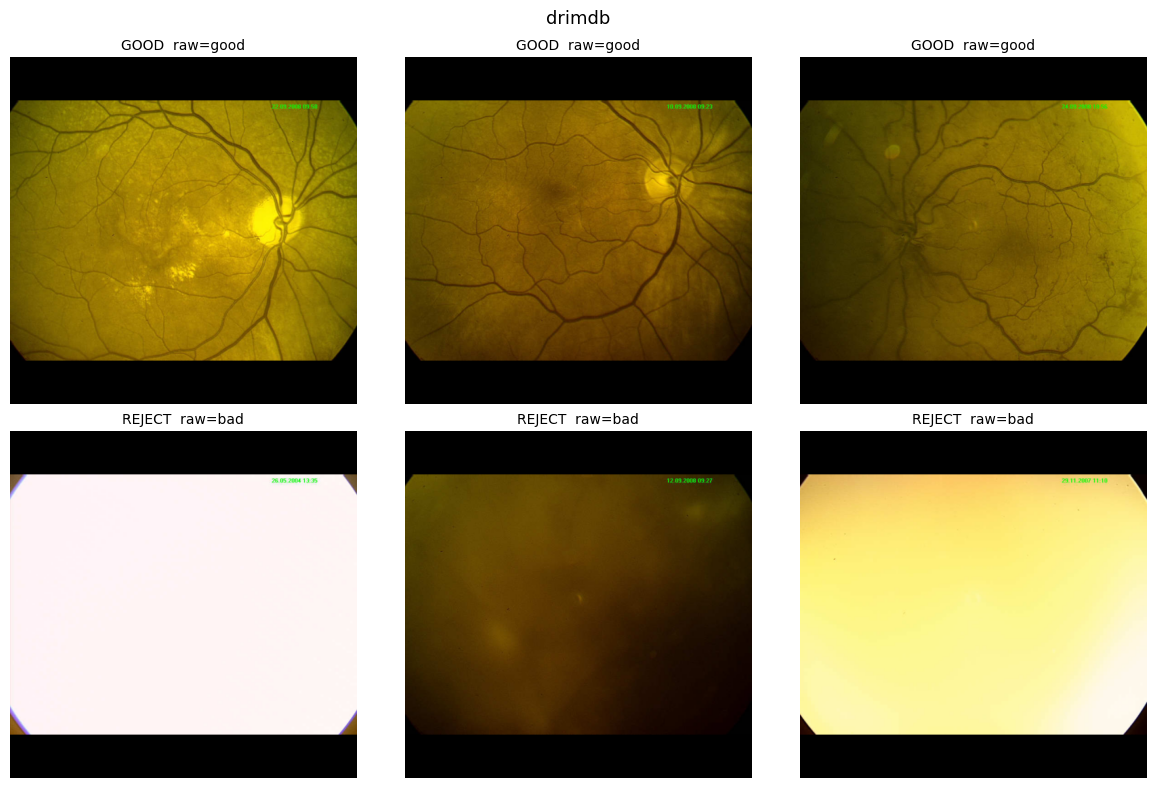

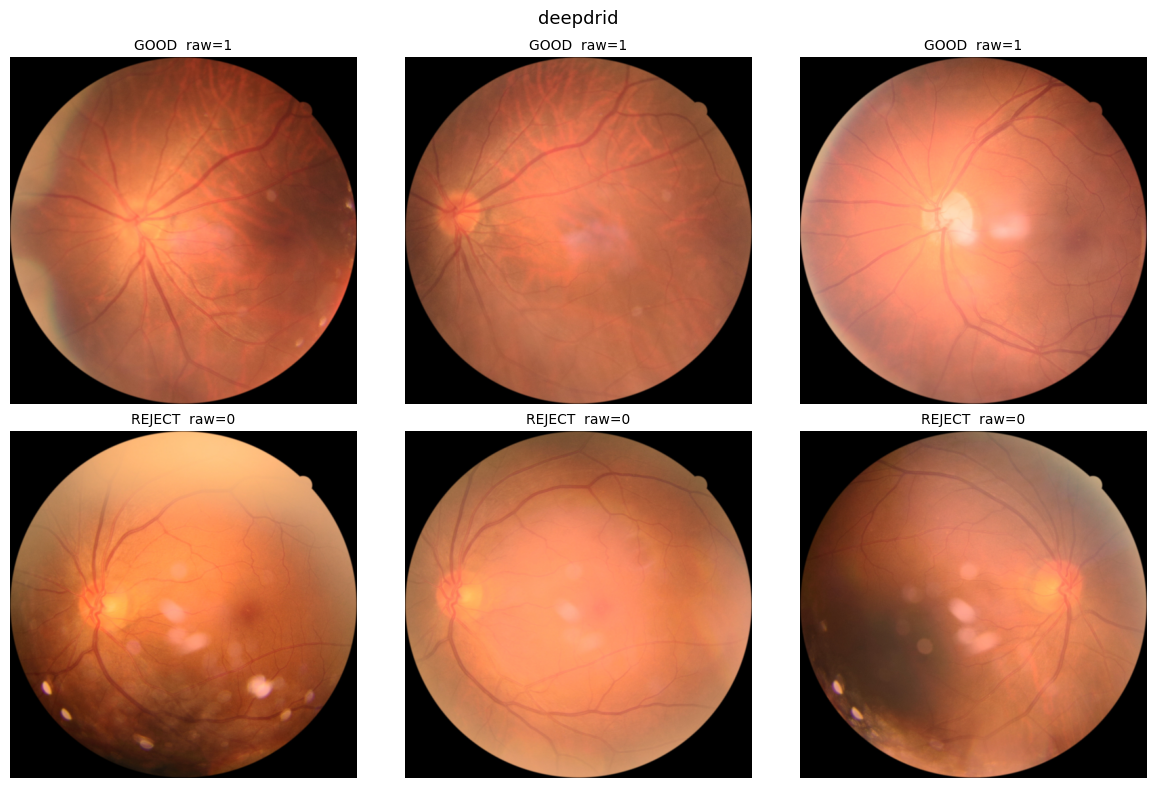

In [18]:
# top row should look clearly better than the bottom row
for ds in manifest[manifest.role == "external"].dataset.unique():
    sub = manifest[manifest.dataset == ds]
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax in axes.ravel():
        ax.axis("off")
    for r, q in enumerate([GOOD, REJECT]):
        for ax, (_, row) in zip(axes[r], sub[sub.quality == q].head(3).iterrows()):
            img = cv2.imread(str(OUT / row.filename))
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{'GOOD' if q == GOOD else 'REJECT'}  "
                         f"raw={row.quality_raw}", fontsize=10)
    plt.suptitle(ds, fontsize=13)
    plt.tight_layout()
    plt.show()

## 9 · Publish

In [19]:
for junk in ["sample", "scratch", "raw"]:
    shutil.rmtree(WORK / junk, ignore_errors=True)

print(sorted(p.name for p in WORK.iterdir()))
!du -sh {OUT}
!df -h /kaggle/working

['.virtual_documents', 'external_512', 'manifest_external_512.csv']
539M	/kaggle/working/external_512
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  539M   19G   3% /kaggle/working


In [20]:
shutil.rmtree(WORK / ".virtual_documents", ignore_errors=True)
print(sorted(p.name for p in WORK.iterdir()))

['external_512', 'manifest_external_512.csv']


Save Version → Save & Run All → Output tab → New Dataset → `retina-external-512`.

Then File → Download and commit to `notebooks/`; loaders into `src/data/load.py`.

### For docs/data-provenance.md

```
DRIMDB   subhajournal/drimdb-diabetic-retinopathy-images-database
         216 files at class-folder top level (Good 125 / Bad 69 / Outlier 22),
         matching Sevik et al. 194 used. Nested iwebalbumfiles/ are iWeb
         gallery exports (thumbnails + web derivatives) and are excluded.
         No patient identifiers - patient_id falls back to image_id.

IDRiD    mohamedabdalkader/indian-diabetic-retinopathy-image-dataset-idrid
         CC BY-SA 4.0; original IEEE DataPort release is CC BY 4.0.
         Upload merges two sources: 516 at 4288x2848 (IDRiD native, matches
         the published count) and 1032 at 4880x3862 (different aspect ratio,
         provenance unknown). Only the 516 native images are used.
         Train and Test each renumber from 0001, so ids are split-prefixed.
         Captions in the upload are not used. Role: pathology control only.

DeepDRiD nancyhisham/deepdrid — mirror of github.com/deepdrdoc/DeepDRiD,
         confirmed by bundled LICENSE and README. Kaggle licence field reads
         Unknown. Citation: Liu et al. (2022), Patterns 3(6):100512.
         regular_fundus_images only; ultra-widefield excluded as a different
         imaging modality. Label direction verified visually on [date].
```

### For docs/targets.md

| Dataset | Expect | Why |
|---|---|---|
| DRIMDB | 95%+ | Visually obvious; published classifiers exceed 98%. Proves less than it looks. |
| DeepDRiD | ~70% | Best in the official ISBI 2020 challenge was 69.81%. Near that is competitive. |
| IDRiD | all Good | Control. Diseased retinas flagged ungradable = learned pathology not quality. |